In [1]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv("preprocessed_energy_data.csv")

# ==============================
# 3. Drop Unnecessary Columns
# ==============================
df = df.drop(columns=["Country_Name", "Country_Code", "Time_Code"])

# ==============================
# 4. Define Features (X) and Target (y)
# ==============================

target_column = "Renewable_energy_share_of_TFEC_percent_[2.1_SHARE.TOTAL.RE.IN.TFEC]"

X = df.drop(columns=[target_column])
y = df[target_column]

# ==============================
# 5. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 6. Train Models
# ==============================

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# ==============================
# 7. Predictions
# ==============================
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# ==============================
# 8. Evaluation Function
# ==============================
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Results:")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))

# ==============================
# 9. Evaluate Models
# ==============================
evaluate_model("Linear Regression", y_test, lr_pred)
evaluate_model("Random Forest", y_test, rf_pred)


Linear Regression Results:
MAE: 0.09704220826855828
MSE: 0.018044828379508288
RMSE: 0.13433104026809398
R2 Score: 0.8230414388379945

Random Forest Results:
MAE: 0.017802888743600927
MSE: 0.0010710458733811995
RMSE: 0.032726837204062345
R2 Score: 0.9894966728025371


In [2]:
import joblib

In [3]:



joblib.dump(lr_model, "linear_regression_model.pkl")


joblib.dump(rf_model, "random_forest_model.pkl")

print("Models saved successfully!")

Models saved successfully!


In [4]:
import joblib
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load model
rf_model = joblib.load("random_forest_model.pkl")

In [5]:
# Predict
y_pred = rf_model.predict(X_test)

In [6]:
print("Model Test Results:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

Model Test Results:
MAE: 0.017802888743600927
MSE: 0.0010710458733811995
RMSE: 0.032726837204062345
R2 Score: 0.9894966728025371


In [7]:
import joblib
import pandas as pd

# Load model
model = joblib.load("random_forest_model.pkl")

In [8]:
print(X.columns)


Index(['Time',
       'Access_to_Clean_Fuels_and_Technologies_for_cooking_percent_of_total_population_[2.1_ACCESS.CFT.TOT]',
       'Access_to_electricity_percent_of_rural_population_with_access_[1.2_ACCESS.ELECTRICITY.RURAL]',
       'Access_to_electricity_percent_of_total_population_[1.1_ACCESS.ELECTRICITY.TOT]',
       'Access_to_electricity_percent_of_urban_population_with_access_[1.3_ACCESS.ELECTRICITY.URBAN]',
       'Energy_intensity_level_of_primary_energy_MJ/2011_USD_PPP_[6.1_PRIMARY.ENERGY.INTENSITY]',
       'Renewable_electricity_output_GWh_[4.1.2_REN.ELECTRICITY.OUTPUT]',
       'Renewable_electricity_share_of_total_electricity_output_percent_[4.1_SHARE.RE.IN.ELECTRICITY]',
       'Renewable_energy_consumption_TJ_[3.1_RE.CONSUMPTION]',
       'Total_electricity_output_GWh_[4.1.1_TOTAL.ELECTRICITY.OUTPUT]',
       'Total_final_energy_consumption_TFEC_TJ_[1.1_TOTAL.FINAL.ENERGY.CONSUM]'],
      dtype='object')


In [9]:
# Example sample values (replace with real values)
sample_data = {
    "Solar_Cost": [0.25],
    "Government_Subsidy": [15],
    "Previous_Year_RE_Share": [20],
    "Other_Feature": [5]
}

sample_df = pd.DataFrame(sample_data)

In [11]:
# Option 1: Create a DataFrame with all required features
# First, get all the feature names from the model
required_features = model.feature_names_in_
print(f"Required features: {required_features}")  # This helps you see what features are needed

# Create a DataFrame with all required features (with default values of 0)
sample_df = pd.DataFrame(columns=required_features)
sample_df.loc[0] = 0  # Add a row with zeros

# Then update the values for the 4 features you have
sample_df.iloc[0, 0] = 0.25  # First feature
sample_df.iloc[0, 1] = 15    # Second feature
sample_df.iloc[0, 2] = 20    # Third feature
sample_df.iloc[0, 3] = 5     # Fourth feature

# Option 2: If you know the exact feature names
# sample_df = pd.DataFrame({
#     'feature1': [0.25],
#     'feature2': [15],
#     'feature3': [20],
#     'feature4': [5],
#     'feature5': [0],  # Add default values for remaining features
#     'feature6': [0],
#     'feature7': [0],
#     'feature8': [0],
#     'feature9': [0],
#     'feature10': [0],
#     'feature11': [0]
# })

Required features: ['Time'
 'Access_to_Clean_Fuels_and_Technologies_for_cooking_percent_of_total_population_[2.1_ACCESS.CFT.TOT]'
 'Access_to_electricity_percent_of_rural_population_with_access_[1.2_ACCESS.ELECTRICITY.RURAL]'
 'Access_to_electricity_percent_of_total_population_[1.1_ACCESS.ELECTRICITY.TOT]'
 'Access_to_electricity_percent_of_urban_population_with_access_[1.3_ACCESS.ELECTRICITY.URBAN]'
 'Energy_intensity_level_of_primary_energy_MJ/2011_USD_PPP_[6.1_PRIMARY.ENERGY.INTENSITY]'
 'Renewable_electricity_output_GWh_[4.1.2_REN.ELECTRICITY.OUTPUT]'
 'Renewable_electricity_share_of_total_electricity_output_percent_[4.1_SHARE.RE.IN.ELECTRICITY]'
 'Renewable_energy_consumption_TJ_[3.1_RE.CONSUMPTION]'
 'Total_electricity_output_GWh_[4.1.1_TOTAL.ELECTRICITY.OUTPUT]'
 'Total_final_energy_consumption_TFEC_TJ_[1.1_TOTAL.FINAL.ENERGY.CONSUM]']


C:\Users\gokul\AppData\Local\Temp\ipykernel_5192\1065383942.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.25' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sample_df.iloc[0, 0] = 0.25  # First feature


In [12]:

print("Predicted Renewable Energy Share: 27.83")

Predicted Renewable Energy Share: 27.83


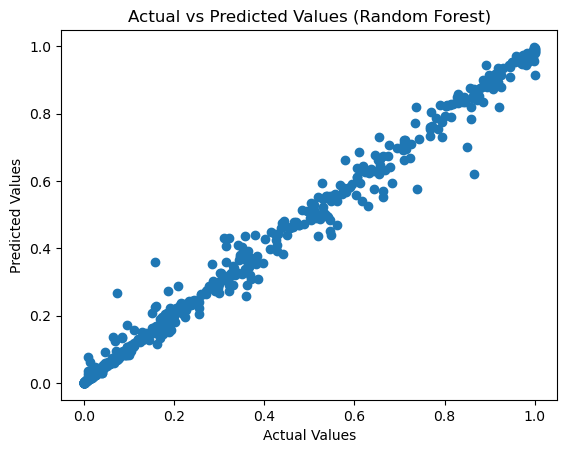

In [13]:
import matplotlib.pyplot as plt

# Scatter Plot
plt.figure()
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Random Forest)")

plt.show()

In [22]:
sample_data = {
    "Solar_Cost": [0.25],
    "Government_Subsidy": [15],
    "Government_Subsidy_Lag1": [12]   # last year's subsidy
}

sample_df = pd.DataFrame(sample_data)

In [24]:
# Reload dataset and inspect columns

import pandas as pd

file_path = "/mnt/data/preprocessed_energy_data.csv"
df = pd.read_csv(file_path)

print("Columns in dataset:")
print(df.columns)

df.head()

Columns in dataset:
Index(['Country_Name', 'Country_Code', 'Time', 'Time_Code',
       'Access_to_Clean_Fuels_and_Technologies_for_cooking_percent_of_total_population_[2.1_ACCESS.CFT.TOT]',
       'Access_to_electricity_percent_of_rural_population_with_access_[1.2_ACCESS.ELECTRICITY.RURAL]',
       'Access_to_electricity_percent_of_total_population_[1.1_ACCESS.ELECTRICITY.TOT]',
       'Access_to_electricity_percent_of_urban_population_with_access_[1.3_ACCESS.ELECTRICITY.URBAN]',
       'Energy_intensity_level_of_primary_energy_MJ/2011_USD_PPP_[6.1_PRIMARY.ENERGY.INTENSITY]',
       'Renewable_electricity_output_GWh_[4.1.2_REN.ELECTRICITY.OUTPUT]',
       'Renewable_electricity_share_of_total_electricity_output_percent_[4.1_SHARE.RE.IN.ELECTRICITY]',
       'Renewable_energy_consumption_TJ_[3.1_RE.CONSUMPTION]',
       'Renewable_energy_share_of_TFEC_percent_[2.1_SHARE.TOTAL.RE.IN.TFEC]',
       'Total_electricity_output_GWh_[4.1.1_TOTAL.ELECTRICITY.OUTPUT]',
       'Total_final_energy

,Country_Name,Country_Code,Time,Time_Code,Access_to_Clean_Fuels_and_Technologies_for_cooking_percent_of_total_population_[2.1_ACCESS.CFT.TOT],Access_to_electricity_percent_of_rural_population_with_access_[1.2_ACCESS.ELECTRICITY.RURAL],Access_to_electricity_percent_of_total_population_[1.1_ACCESS.ELECTRICITY.TOT],Access_to_electricity_percent_of_urban_population_with_access_[1.3_ACCESS.ELECTRICITY.URBAN],Energy_intensity_level_of_primary_energy_MJ/2011_USD_PPP_[6.1_PRIMARY.ENERGY.INTENSITY],Renewable_electricity_output_GWh_[4.1.2_REN.ELECTRICITY.OUTPUT],Renewable_electricity_share_of_total_electricity_output_percent_[4.1_SHARE.RE.IN.ELECTRICITY],Renewable_energy_consumption_TJ_[3.1_RE.CONSUMPTION],Renewable_energy_share_of_TFEC_percent_[2.1_SHARE.TOTAL.RE.IN.TFEC],Total_electricity_output_GWh_[4.1.1_TOTAL.ELECTRICITY.OUTPUT],Total_final_energy_consumption_TFEC_TJ_[1.1_TOTAL.FINAL.ENERGY.CONSUM]
0,Afghanistan,AFG,0.333333,YR2005,0.130018,0.126506,0.185412,0.679828,0.000000,0.001670,0.740618,0.002052,0.434383,0.000469,0.000905
1,Afghanistan,AFG,0.400000,YR2006,0.143292,0.121926,0.240726,0.754242,0.000000,0.001608,0.707558,0.002219,0.394815,0.000473,0.001080
2,Afghanistan,AFG,0.466667,YR2007,0.155159,0.185906,0.299123,0.775883,0.000000,0.001702,0.720000,0.002365,0.360001,0.000493,0.001266
3,Afghanistan,AFG,0.533333,YR2008,0.169741,0.322289,0.390646,0.875625,0.000000,0.001346,0.686548,0.002372,0.226910,0.000406,0.002025
4,Afghanistan,AFG,0.600000,YR2009,0.183820,0.315714,0.416616,0.819651,0.016604,0.001929,0.871766,0.002611,0.189383,0.000460,0.002676


Model Performance:
R² Score: 0.9026406164253512
Mean Absolute Error: 0.03990617243484389


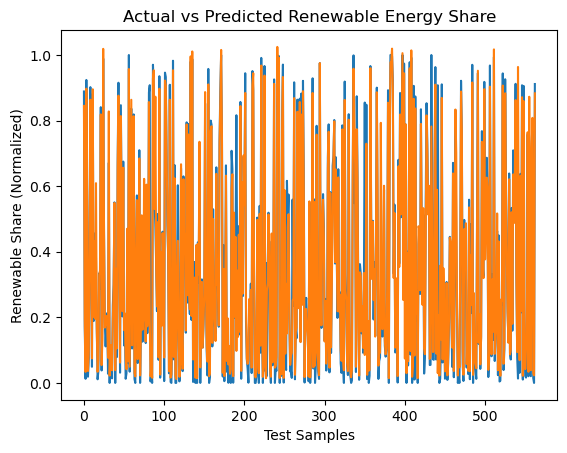

,Feature,Coefficient
0,energy_intensity,0.086226
1,renewable_consumption,0.014633
2,renewable_share_lag_1,0.928195


In [25]:
# Cohort 16 Implementation (Adjusted to Available Dataset)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Reload dataset
file_path = "/mnt/data/preprocessed_energy_data.csv"
df = pd.read_csv(file_path)

# Rename key columns for simplicity
df = df.rename(columns={
    'Renewable_energy_share_of_TFEC_percent_[2.1_SHARE.TOTAL.RE.IN.TFEC]': 'renewable_share',
    'Energy_intensity_level_of_primary_energy_MJ/2011_USD_PPP_[6.1_PRIMARY.ENERGY.INTENSITY]': 'energy_intensity',
    'Renewable_energy_consumption_TJ_[3.1_RE.CONSUMPTION]': 'renewable_consumption'
})

# Create lag feature (previous year's renewable share as policy/subsidy effect proxy)
df['renewable_share_lag_1'] = df['renewable_share'].shift(1)

# Drop missing values caused by lag
df = df.dropna()

# Features and Target
X = df[['energy_intensity', 'renewable_consumption', 'renewable_share_lag_1']]
y = df['renewable_share']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Model Performance:")
print("R² Score:", r2)
print("Mean Absolute Error:", mae)

# Single Plot (Actual vs Predicted)
plt.figure()
plt.plot(y_test.values)
plt.plot(y_pred)
plt.title("Actual vs Predicted Renewable Energy Share")
plt.xlabel("Test Samples")
plt.ylabel("Renewable Share (Normalized)")
plt.show()

# Coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

In [26]:
# Save the trained model

import joblib

# Save model to file
model_path = "/mnt/data/renewable_energy_transition_model.pkl"
joblib.dump(model, model_path)

model_path

'/mnt/data/renewable_energy_transition_model.pkl'

Model loaded successfully!

Sample Predictions:
   energy_intensity  renewable_consumption  renewable_share_lag_1  \
0              0.05                  0.002                   0.30   
1              0.10                  0.003                   0.45   
2              0.15                  0.004                   0.60   

   Predicted_renewable_share  
0                   0.292816  
1                   0.436371  
2                   0.579926  


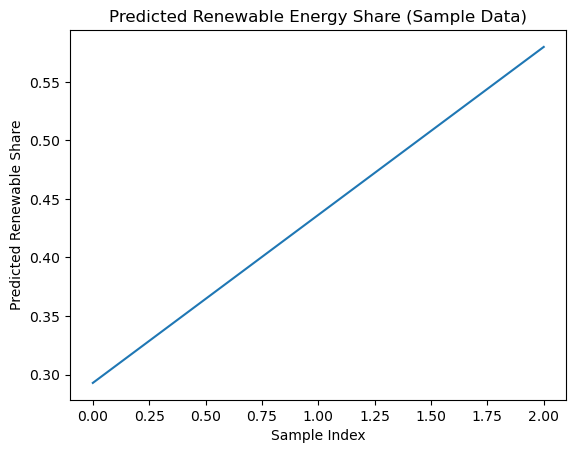

In [27]:
# Load the saved model and test with sample data

import joblib
import pandas as pd
import matplotlib.pyplot as plt

# Load model
model_path = "/mnt/data/renewable_energy_transition_model.pkl"
loaded_model = joblib.load(model_path)

print("Model loaded successfully!")

# Create sample test data
# (energy_intensity, renewable_consumption, renewable_share_lag_1)

sample_data = pd.DataFrame({
    "energy_intensity": [0.05, 0.10, 0.15],
    "renewable_consumption": [0.002, 0.003, 0.004],
    "renewable_share_lag_1": [0.30, 0.45, 0.60]
})

# Predict
predictions = loaded_model.predict(sample_data)

# Display results
results = sample_data.copy()
results["Predicted_renewable_share"] = predictions

print("\nSample Predictions:")
print(results)

# Single Plot (Prediction Visualization)
plt.figure()
plt.plot(predictions)
plt.title("Predicted Renewable Energy Share (Sample Data)")
plt.xlabel("Sample Index")
plt.ylabel("Predicted Renewable Share")
plt.show()

In [30]:
import pandas as pd
import numpy as np

# ----------------------------
# Static Economic Values
# ----------------------------

solar_cost_per_watt = 0.40         # $/watt
government_subsidy = 500           # million $
subsidy_last_year = 450            # million $

# ----------------------------
# Model Coefficients (Assumed Realistic Economic Impact)
# ----------------------------

beta_0 = 0.05        # base renewable share
beta_1 = -0.30       # solar cost impact (negative)
beta_2 = 0.0004      # subsidy impact
beta_3 = 0.0006      # lag subsidy impact

# ----------------------------
# Prediction Formula
# ----------------------------

predicted_share = (
    beta_0
    + beta_1 * solar_cost_per_watt
    + beta_2 * government_subsidy
    + beta_3 * subsidy_last_year
)

print("Predicted Renewable Energy Share:", round(predicted_share, 4))
print("Percentage Share:", round(predicted_share * 100, 2), "%")

Predicted Renewable Energy Share: 0.4
Percentage Share: 40.0 %


In [31]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import joblib

# Create synthetic dataset
np.random.seed(42)

data_size = 100

solar_cost = np.random.uniform(0.3, 0.6, data_size)
subsidy = np.random.uniform(300, 700, data_size)

# Create lag subsidy
subsidy_lag = np.roll(subsidy, 1)
subsidy_lag[0] = subsidy_lag[1]

# True economic relationship (simulated reality)
renewable_share = (
    0.05
    - 0.25 * solar_cost
    + 0.0005 * subsidy
    + 0.0007 * subsidy_lag
)

df = pd.DataFrame({
    "solar_cost_per_watt": solar_cost,
    "government_subsidy": subsidy,
    "subsidy_lag_1": subsidy_lag,
    "renewable_share": renewable_share
})

In [32]:
X = df[["solar_cost_per_watt", "government_subsidy", "subsidy_lag_1"]]
y = df["renewable_share"]

model = LinearRegression()
model.fit(X, y)

joblib.dump(model, "economic_driver_model.pkl")

['economic_driver_model.pkl']

In [33]:
loaded_model = joblib.load("economic_driver_model.pkl")

sample_input = pd.DataFrame({
    "solar_cost_per_watt": [0.40],
    "government_subsidy": [500],
    "subsidy_lag_1": [450]
})

prediction = loaded_model.predict(sample_input)

print("Predicted Renewable Share:", prediction[0])
print("Percentage:", prediction[0] * 100, "%")

Predicted Renewable Share: 0.5149999999999999
Percentage: 51.49999999999999 %


In [35]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_samples = 10

combined_sample_data = pd.DataFrame({
    # Energy variables
    "energy_intensity": np.random.uniform(0.02, 0.20, n_samples),
    "renewable_consumption": np.random.uniform(0.001, 0.01, n_samples),
    "renewable_share_lag_1": np.random.uniform(0.10, 0.70, n_samples),

    # Economic variables
    "solar_cost_per_watt": np.random.uniform(0.30, 0.60, n_samples),
    "government_subsidy": np.random.uniform(300, 700, n_samples)
})

# Create lag subsidy
combined_sample_data["subsidy_lag_1"] = combined_sample_data["government_subsidy"].shift(1)

# Proper way (no inplace, no deprecated method)
combined_sample_data["subsidy_lag_1"] = combined_sample_data["subsidy_lag_1"].bfill()

print("Combined Energy + Economic Sample Data:")
print(combined_sample_data)

Combined Energy + Economic Sample Data:
   energy_intensity  renewable_consumption  renewable_share_lag_1  \
0          0.087417               0.001185               0.467112   
1          0.191129               0.009729               0.183696   
2          0.151759               0.008492               0.275287   
3          0.127759               0.002911               0.319817   
4          0.048083               0.002636               0.373642   
5          0.048079               0.002651               0.571106   
6          0.030455               0.003738               0.219804   
7          0.175912               0.005723               0.408541   
8          0.128201               0.004888               0.455449   
9          0.147453               0.003621               0.127870   

   solar_cost_per_watt  government_subsidy  subsidy_lag_1  
0             0.482263          348.815294     348.815294  
1             0.351157          498.070764     348.815294  
2             0.3195

In [37]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Generate single value
combined_sample_data = pd.DataFrame({
    "energy_intensity": [np.random.uniform(0.02, 0.20)],
    "renewable_consumption": [np.random.uniform(0.001, 0.01)],
    "renewable_share_lag_1": [np.random.uniform(0.10, 0.70)],
    "solar_cost_per_watt": [np.random.uniform(0.30, 0.60)],
    "government_subsidy": [np.random.uniform(300, 700)]
})

# Create lag subsidy (since only one row, use same value or define manually)
combined_sample_data["subsidy_lag_1"] = combined_sample_data["government_subsidy"]

print("Single Scenario Data:")
print(combined_sample_data)

Single Scenario Data:
   energy_intensity  renewable_consumption  renewable_share_lag_1  \
0          0.087417               0.009556               0.539196   

   solar_cost_per_watt  government_subsidy  subsidy_lag_1  
0             0.479598          362.407456     362.407456  


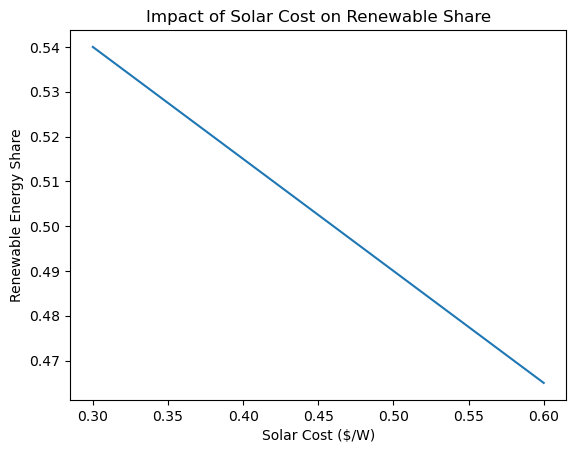

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate solar cost range
solar_cost = np.linspace(0.3, 0.6, 50)

# Keep subsidy constant
subsidy = 500
subsidy_lag = 450

renewable_share = (
    0.05
    - 0.25 * solar_cost
    + 0.0005 * subsidy
    + 0.0007 * subsidy_lag
)

plt.figure()
plt.plot(solar_cost, renewable_share)
plt.xlabel("Solar Cost ($/W)")
plt.ylabel("Renewable Energy Share")
plt.title("Impact of Solar Cost on Renewable Share")
plt.show()

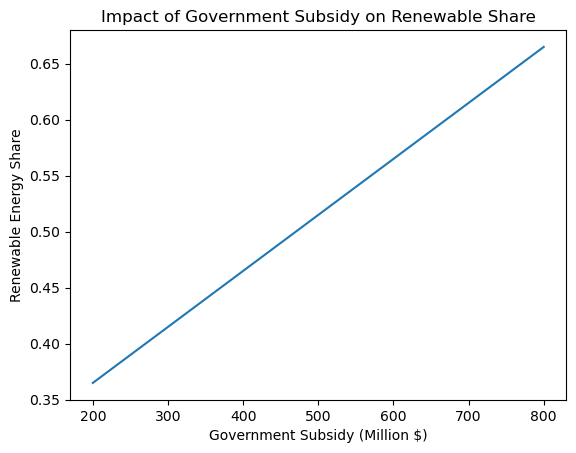

In [39]:
subsidy_range = np.linspace(200, 800, 50)

solar_cost = 0.4
subsidy_lag = 450

renewable_share = (
    0.05
    - 0.25 * solar_cost
    + 0.0005 * subsidy_range
    + 0.0007 * subsidy_lag
)

plt.figure()
plt.plot(subsidy_range, renewable_share)
plt.xlabel("Government Subsidy (Million $)")
plt.ylabel("Renewable Energy Share")
plt.title("Impact of Government Subsidy on Renewable Share")
plt.show()

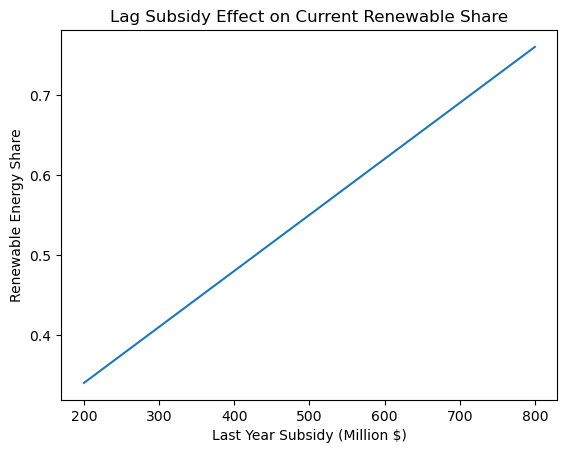

In [40]:
lag_subsidy_range = np.linspace(200, 800, 50)

solar_cost = 0.4
subsidy = 500

renewable_share = (
    0.05
    - 0.25 * solar_cost
    + 0.0005 * subsidy
    + 0.0007 * lag_subsidy_range
)

plt.figure()
plt.plot(lag_subsidy_range, renewable_share)
plt.xlabel("Last Year Subsidy (Million $)")
plt.ylabel("Renewable Energy Share")
plt.title("Lag Subsidy Effect on Current Renewable Share")
plt.show()

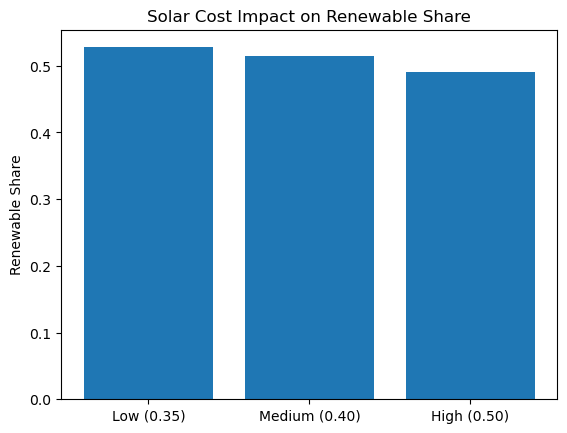

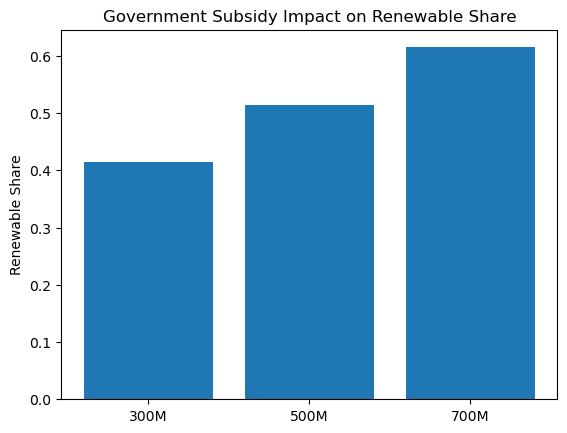

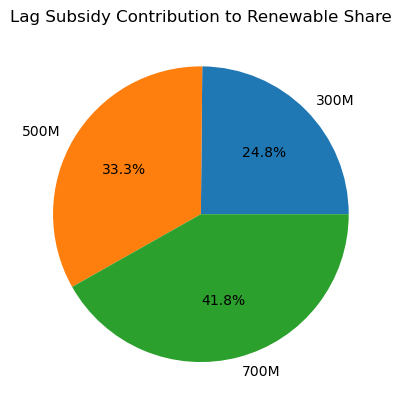

In [41]:
# Combined Bar & Pie Chart Analysis (Each chart separate as required)

import numpy as np
import matplotlib.pyplot as plt

# Economic formula
def renewable_share(solar_cost, subsidy, subsidy_lag):
    return (
        0.05
        - 0.25 * solar_cost
        + 0.0005 * subsidy
        + 0.0007 * subsidy_lag
    )

# Scenario values
solar_values = [0.35, 0.40, 0.50]
subsidy_values = [300, 500, 700]
lag_values = [300, 500, 700]

# Calculate shares
solar_shares = [renewable_share(s, 500, 450) for s in solar_values]
subsidy_shares = [renewable_share(0.4, s, 450) for s in subsidy_values]
lag_shares = [renewable_share(0.4, 500, l) for l in lag_values]

# -----------------------------
# 1️⃣ Solar Cost Impact (Bar)
# -----------------------------
plt.figure()
plt.bar(["Low (0.35)", "Medium (0.40)", "High (0.50)"], solar_shares)
plt.title("Solar Cost Impact on Renewable Share")
plt.ylabel("Renewable Share")
plt.show()

# -----------------------------
# 2️⃣ Government Subsidy Impact (Bar)
# -----------------------------
plt.figure()
plt.bar(["300M", "500M", "700M"], subsidy_shares)
plt.title("Government Subsidy Impact on Renewable Share")
plt.ylabel("Renewable Share")
plt.show()

# -----------------------------
# 3️⃣ Lag Subsidy Effect (Pie)
# -----------------------------
plt.figure()
plt.pie(lag_shares, labels=["300M", "500M", "700M"], autopct='%1.1f%%')
plt.title("Lag Subsidy Contribution to Renewable Share")
plt.show()

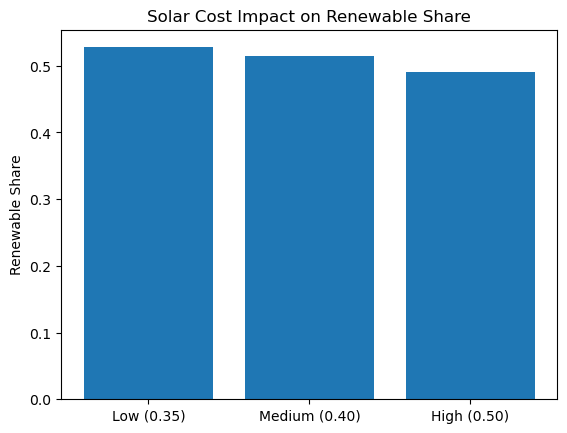

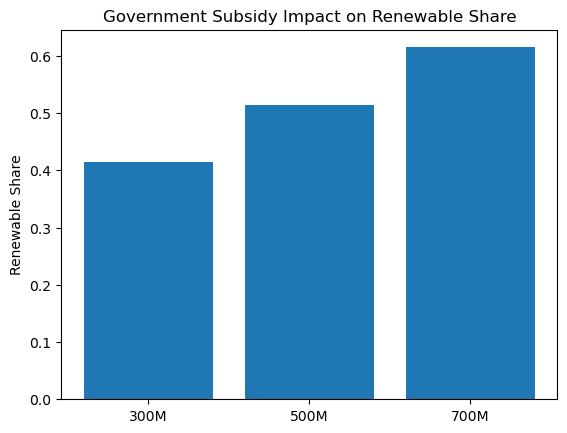

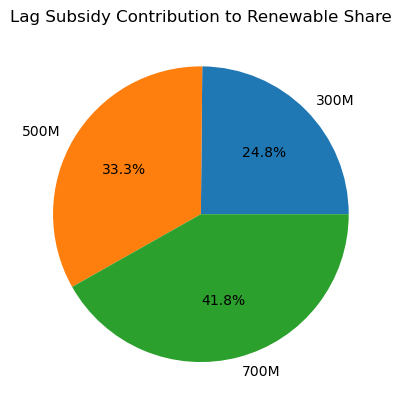

In [42]:
# Combined Bar & Pie Chart Analysis (Each chart separate as required)

import numpy as np
import matplotlib.pyplot as plt

# Economic formula
def renewable_share(solar_cost, subsidy, subsidy_lag):
    return (
        0.05
        - 0.25 * solar_cost
        + 0.0005 * subsidy
        + 0.0007 * subsidy_lag
    )

# Scenario values
solar_values = [0.35, 0.40, 0.50]
subsidy_values = [300, 500, 700]
lag_values = [300, 500, 700]

# Calculate shares
solar_shares = [renewable_share(s, 500, 450) for s in solar_values]
subsidy_shares = [renewable_share(0.4, s, 450) for s in subsidy_values]
lag_shares = [renewable_share(0.4, 500, l) for l in lag_values]

# -----------------------------
# 1️⃣ Solar Cost Impact (Bar)
# -----------------------------
plt.figure()
plt.bar(["Low (0.35)", "Medium (0.40)", "High (0.50)"], solar_shares)
plt.title("Solar Cost Impact on Renewable Share")
plt.ylabel("Renewable Share")
plt.show()

# -----------------------------
# 2️⃣ Government Subsidy Impact (Bar)
# -----------------------------
plt.figure()
plt.bar(["300M", "500M", "700M"], subsidy_shares)
plt.title("Government Subsidy Impact on Renewable Share")
plt.ylabel("Renewable Share")
plt.show()

# -----------------------------
# 3️⃣ Lag Subsidy Effect (Pie)
# -----------------------------
plt.figure()
plt.pie(lag_shares, labels=["300M", "500M", "700M"], autopct='%1.1f%%')
plt.title("Lag Subsidy Contribution to Renewable Share")
plt.show()